<div style='background-image: url("../share/images/header.svg") ; padding: 0px ; background-size: cover ; border-radius: 5px ; height: 250px'>
    <div style="float: right ; margin: 50px ; padding: 20px ; background: rgba(255 , 255 , 255 , 0.7) ; width: 50% ; height: 150px">
        <div style="position: relative ; top: 50% ; transform: translatey(-50%)">
            <div style="font-size: xx-large ; font-weight: 900 ; color: rgba(0 , 0 , 0 , 0.8) ; line-height: 100%">ObsPy Tutorial</div>
            <div style="font-size: large ; padding-top: 20px ; color: rgba(0 , 0 , 0 , 0.5)">Downloading/Processing Exercise</div>
        </div>
    </div>
</div>

Seismo-Live: http://seismo-live.org

##### Authors:
* Lion Krischer ([@krischer](https://github.com/krischer))
* Tobias Megies ([@megies](https://github.com/megies))
---

For the this exercise we will download some data from the Tohoku-Oki earthquake, cut out a certain time window around the first arrival and remove the instrument response from the data.

In [2]:
from __future__ import print_function

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 12, 8

The first step is to download all the necessary information using the ObsPy FDSN client. **Learn to read the documentation!**

We need the following things:

1. Event information about the Tohoku-Oki earthquake. Use the `get_events()` method of the client. A good provider of event data is the USGS.
2. Waveform information for a certain station. Choose your favorite one! If you have no preference, use `II.BFO` which is available for example from IRIS. Use the `get_waveforms()` method.
3. Download the associated station/instrument information with the `get_stations()` method.

In [4]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

client_usgs = Client("USGS")
client_earthscope = Client("EARTHSCOPE") # Updated from "IRIS"

# 1. Event information about the Tohoku-Oki earthquake (March 11, 2011)
t = UTCDateTime("2011-03-11T05:46:24")
cat = client_usgs.get_events(starttime=t-100, endtime=t+100, minmagnitude=8.5)
event = cat[0]
origin = event.origins[0]

# 2. Waveform information for station II.BFO 
st = client_earthscope.get_waveforms(network="II", station="BFO", location="00", channel="BHZ", 
                                     starttime=origin.time, endtime=origin.time + 7200)


inv = client_earthscope.get_stations(network="II", station="BFO", level="response", 
                                     starttime=origin.time, endtime=origin.time + 7200)

Have a look at the just downloaded data.

## Exercise

The goal of this exercise is to cut the data from 1 minute before the first arrival to 5 minutes after it, and then remove the instrument response.


#### Step 1: Determine Coordinates of Station

In [5]:
station = inv[0][0]
sta_lat = station.latitude
sta_lon = station.longitude

print(f"Station Coordinates: Latitude={sta_lat}, Longitude={sta_lon}")

Station Coordinates: Latitude=48.3301, Longitude=8.3296


#### Step 2: Determine Coordinates of Event

In [6]:
ev_lat = origin.latitude
ev_lon = origin.longitude
ev_depth_km = origin.depth / 1000.0  

print(f"Event Coordinates: Latitude={ev_lat}, Longitude={ev_lon}, Depth={ev_depth_km} km")

Event Coordinates: Latitude=38.297, Longitude=142.373, Depth=29.0 km


#### Step 3: Calculate distance of event and station.

Use `obspy.geodetics.locations2degree`.

In [7]:
from obspy.geodetics import locations2degrees

distance = locations2degrees(ev_lat, ev_lon, sta_lat, sta_lon)
print(f"Distance: {distance:.2f} degrees")

Distance: 84.25 degrees


#### Step 4: Calculate Theoretical Arrivals

```python
from obspy.taup import TauPyModel
m = TauPyModel(model="ak135")
arrivals = m.get_ray_paths(...)
arrivals.plot()
```

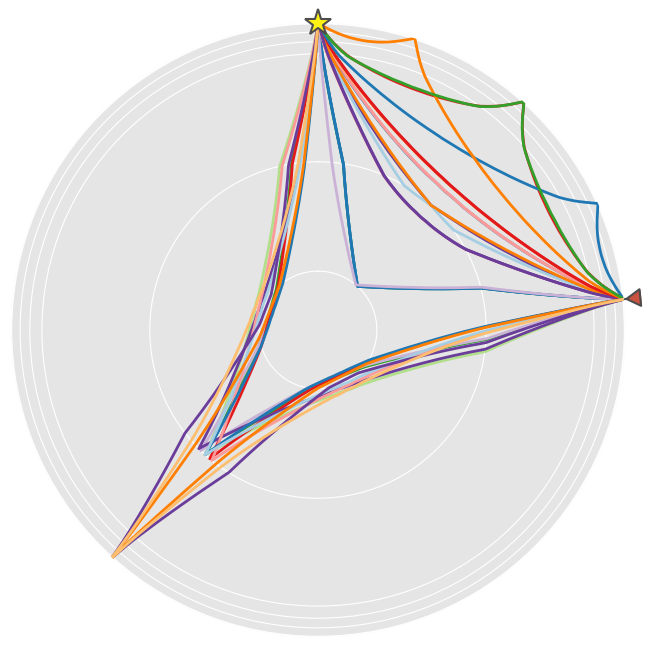

<PolarAxes: >

In [9]:
from obspy.taup import TauPyModel

m = TauPyModel(model="ak135")
arrivals = m.get_ray_paths(source_depth_in_km=ev_depth_km, distance_in_degree=distance)

arrivals.plot_rays()

#### Step 5: Calculate absolute time of the first arrivals at the station

In [10]:
first_arrival = arrivals[0]
first_arrival_time = origin.time + first_arrival.time

print(f"Absolute time of first arrival: {first_arrival_time}")

Absolute time of first arrival: 2011-03-11T05:58:52.936406Z


#### Step 6:  Cut to 1 minute before and 5 minutes after the first arrival

In [11]:
t_start = first_arrival_time - 60   
t_end = first_arrival_time + 300    

st_cut = st.slice(starttime=t_start, endtime=t_end)
print(st_cut)

1 Trace(s) in Stream:
II.BFO.00.BHZ | 2011-03-11T05:57:52.916895Z - 2011-03-11T06:03:52.916895Z | 20.0 Hz, 7201 samples


#### Step 7: Remove the instrument response

```python
st.remove_response(inventory=inv, pre_filt=...)
```

![taper](images/cos_taper.png)

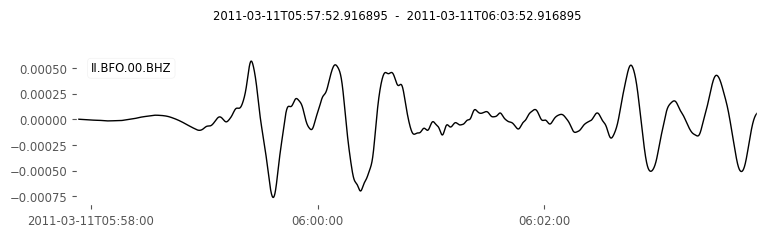

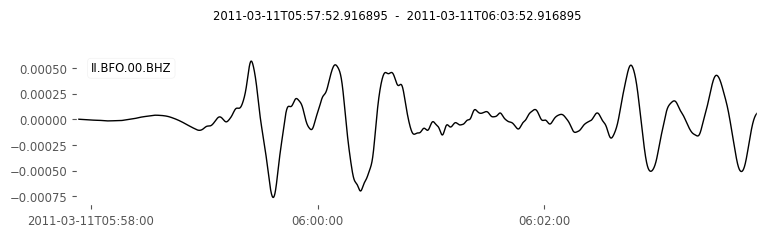

In [12]:
pre_filt = [0.015, 0.025, 0.25, 0.4]

st_cut.remove_response(inventory=inv, pre_filt=pre_filt, output="DISP", water_level=60)
st_cut.plot()